**Importação de bibliotecas**

In [1]:
import matplotlib.dates as mdates

import matplotlib.pyplot as plt
import itertools
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns
import warnings
import os

import datetime
import numpy as np

# **Inserindo dados**


Vamos utilizar dados da Magalu para análisar com séries temporais, no período entre 1° de abrilde 2022 até 1° de abril de 2024

In [4]:
import yfinance as yf

# Defina o ticker do ativo
ticker = 'MGLU3.SA'

# Baixe os dados históricos
df = yf.download(ticker, start='2022-04-01', end='2024-04-01')

# Visualizando os dados
print(df)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker       MGLU3.SA   MGLU3.SA   MGLU3.SA   MGLU3.SA  MGLU3.SA
Date                                                            
2022-04-01  63.560612  63.820042  59.496193  59.842100  15934623
2022-04-04  62.176979  63.647091  60.793346  63.560612  11149019
2022-04-05  59.755627  63.820045  59.323241  62.004027  12348524
2022-04-06  57.247791  59.063810  55.777683  58.890855  13361138
2022-04-07  56.728928  59.150283  55.950632  56.988358  14524181
...               ...        ...        ...        ...       ...
2024-03-22  17.751709  18.213993  16.734684  18.121537  22430100
2024-03-25  17.659252  17.936623  17.104512  17.751709  16300588
2024-03-26  16.457314  17.659253  16.457314  17.566797  16824297
2024-03-27  16.827141  16.919599  15.902574  16.457313  14986461
2024-03-28  16.642227  17.104511  16.549771  16.734684  10956309

[497 rows x 5 columns]


# **Checagem dos dados**

In [3]:
# Verificando dados vazios
print("Dados vazios")
print(df.info())
print()

# Verificando se há algum valor vazio
print("Dados NA")
print(df.isna().any())
print()

# Verificando quantidade
print("Quantidade de dados NA")
print(df.isna().sum())
print()

Dados vazios
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 497 entries, 2022-04-01 to 2024-03-28
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, MGLU3.SA)   497 non-null    float64
 1   (High, MGLU3.SA)    497 non-null    float64
 2   (Low, MGLU3.SA)     497 non-null    float64
 3   (Open, MGLU3.SA)    497 non-null    float64
 4   (Volume, MGLU3.SA)  497 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.3 KB
None

Dados NA
Price   Ticker  
Close   MGLU3.SA    False
High    MGLU3.SA    False
Low     MGLU3.SA    False
Open    MGLU3.SA    False
Volume  MGLU3.SA    False
dtype: bool

Quantidade de dados NA
Price   Ticker  
Close   MGLU3.SA    0
High    MGLU3.SA    0
Low     MGLU3.SA    0
Open    MGLU3.SA    0
Volume  MGLU3.SA    0
dtype: int64



Formato das datas


In [4]:
# Verificando se o índice está no formato datetime
try:
    pd.to_datetime(df.index)
    print("O índice está no formato datetime.")
except ValueError:
    print("O índice não está no formato datetime.")

O índice está no formato datetime.


In [5]:
print(df.dtypes)

Price   Ticker  
Close   MGLU3.SA    float64
High    MGLU3.SA    float64
Low     MGLU3.SA    float64
Open    MGLU3.SA    float64
Volume  MGLU3.SA      int64
dtype: object


# **Caso não estivesse em datetime:**

In [ ]:
# Criando uma nova coluna que copia o índice
df['Date'] = df.index

# Verificando o dfFrame após a modificação
print(df)

                Open      High       Low     Close  Adj Close     Volume  \
Date                                                                       
2022-04-01  6.472437  6.902686  6.435024  6.874626   6.874626  151758321   
2022-04-04  6.874626  6.883979  6.575323  6.724974   6.724974  106181141   
2022-04-05  6.706268  6.902686  6.416318  6.463084   6.463084  117604998   
2022-04-06  6.369551  6.388258  6.032835  6.191840   6.191840  127248936   
2022-04-07  6.163780  6.397611  6.051541  6.135721   6.135721  138325533   
...              ...       ...       ...       ...        ...        ...   
2024-03-22  1.960000  1.970000  1.810000  1.920000   1.920000  213620000   
2024-03-25  1.920000  1.940000  1.850000  1.910000   1.910000  155243700   
2024-03-26  1.900000  1.910000  1.780000  1.780000   1.780000  160231400   
2024-03-27  1.780000  1.830000  1.720000  1.820000   1.820000  142728200   
2024-03-28  1.810000  1.850000  1.790000  1.800000   1.800000  104345800   

           

In [ ]:
print(df.dtypes)

Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Date         datetime64[ns]
dtype: object


Precisamos que o índice seja date time para as análises que iremos utilizar

Verificando se a coluna está no formato date time

In [ ]:
# Verificando se a coluna 'df' está no formato datetime
try:
    pd.to_datetime(df['Date'])
    print("A coluna 'Date' está no formato datetime.")
except ValueError:
    print("A coluna 'Date' não está no formato datetime.")

A coluna 'Date' está no formato datetime.


Para converter para date time se precisar

In [ ]:
# Convertendo a coluna 'Date' para datetime
df['Date'] = pd.to_datetime(df['Date'], unit='s', format='%m%d%Y')

In [ ]:
print(df["Date"])

Date
2022-04-01   2022-04-01
2022-04-04   2022-04-04
2022-04-05   2022-04-05
2022-04-06   2022-04-06
2022-04-07   2022-04-07
                ...    
2024-03-22   2024-03-22
2024-03-25   2024-03-25
2024-03-26   2024-03-26
2024-03-27   2024-03-27
2024-03-28   2024-03-28
Name: Date, Length: 497, dtype: datetime64[ns]


Definindo como índice

In [ ]:
# Definindo a coluna 'df' como índice
df.set_index('Date', inplace=True)

# Verificando o dfFrame após a modificação
print(df)

                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2022-04-01  6.472437  6.902686  6.435024  6.874626   6.874626  151758321
2022-04-04  6.874626  6.883979  6.575323  6.724974   6.724974  106181141
2022-04-05  6.706268  6.902686  6.416318  6.463084   6.463084  117604998
2022-04-06  6.369551  6.388258  6.032835  6.191840   6.191840  127248936
2022-04-07  6.163780  6.397611  6.051541  6.135721   6.135721  138325533
...              ...       ...       ...       ...        ...        ...
2024-03-22  1.960000  1.970000  1.810000  1.920000   1.920000  213620000
2024-03-25  1.920000  1.940000  1.850000  1.910000   1.910000  155243700
2024-03-26  1.900000  1.910000  1.780000  1.780000   1.780000  160231400
2024-03-27  1.780000  1.830000  1.720000  1.820000   1.820000  142728200
2024-03-28  1.810000  1.850000  1.790000  1.800000   1.800000  104205500

[497 rows x 6 columns]


# **Visualização da série temporal**


Verificando preços de abertura e fechamento

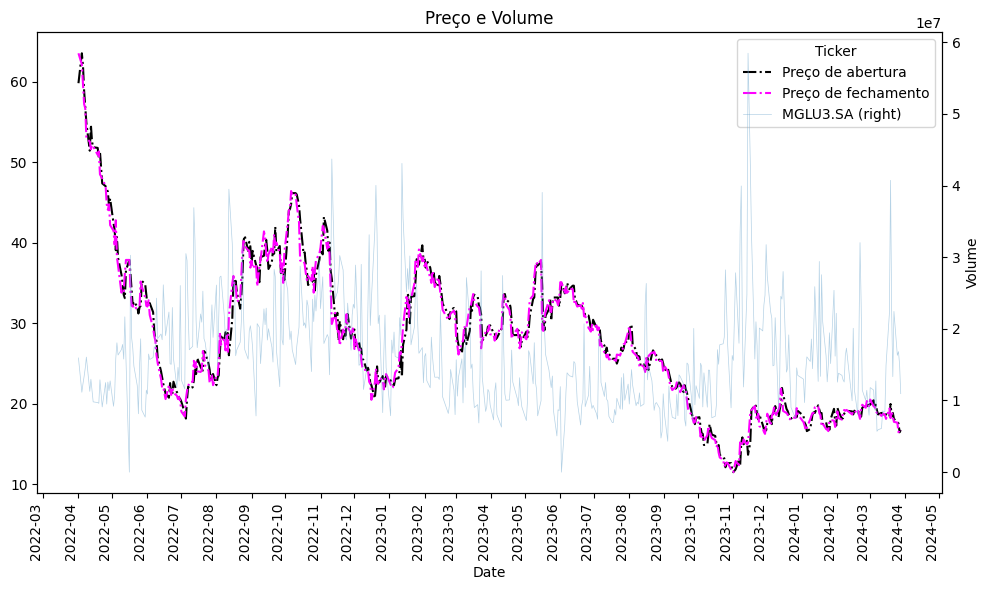

In [7]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'Adj Close'
df.plot(y=['Open', 'Close'], color=['black', 'magenta'], ls='-.', ax=ax, label=['Preço de abertura','Preço de fechamento'])

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

Aqui temos uma série temporal real.

Cada ponto representa o preço da ação ao longo do tempo.

**Perguntas**

- O comportamento parece estável?

 - Existe tendência?

- Parece fácil prever?

**Verificando preços máximos e mínimos**

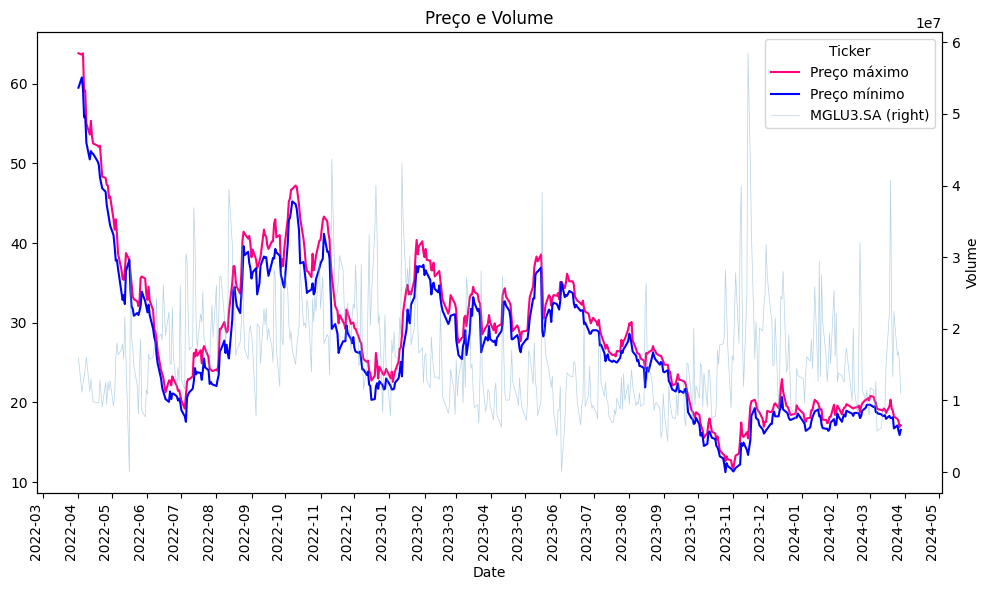

In [8]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'High' e 'Low'
df.plot(y=['High', 'Low'], color=['#FF007F', 'blue'], ax=ax, label=['Preço máximo', 'Preço mínimo'])

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

Visualizando preço médio

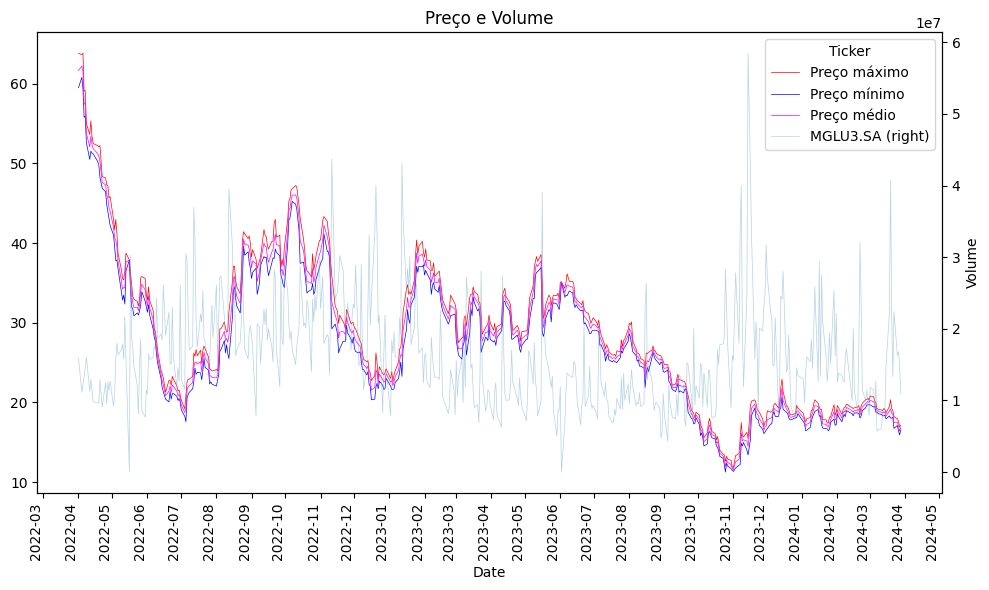

In [9]:
# Calcular o preço médio
df['Average'] = (df['High'] + df['Low']) / 2

# Plotar o gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'High', 'Low' e 'Average'
df.plot(y=['High', 'Low', 'Average'], color=['red', 'blue', 'magenta'], ax=ax,
        label=['Preço máximo', 'Preço mínimo', 'Preço médio'], linewidth=0.5)

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

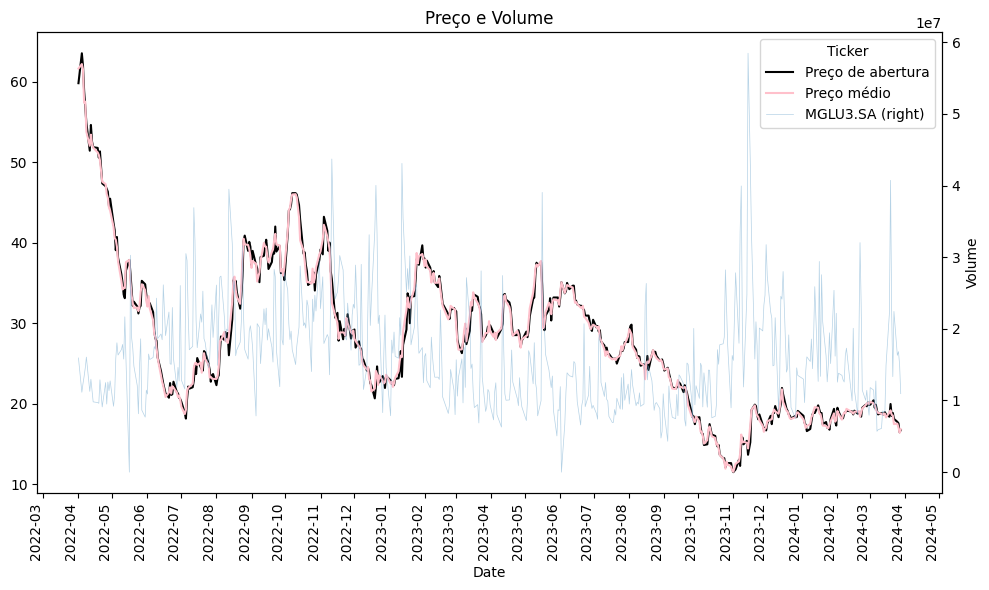

In [11]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plotar o gráfico de linha para 'Adj Close'
df.plot(y=['Open','Average'], color=['black', 'pink'], ls='solid', ax=ax, label=['Preço de abertura','Preço médio'])

# Criar um segundo eixo y para 'Volume'
ax1 = df.plot(y='Volume', secondary_y=True, color='#6CA6CD', ax=ax, alpha=0.5, rot=0, lw=0.5)
ax1.set(ylabel='Volume')

# Definir o eixo y para 'Volume'
ax1.set_ylabel('Volume')

# Definir a escala do eixo x para exibir apenas os meses
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotacionar os rótulos do eixo x em 90 graus
ax.tick_params(axis='x', rotation=90)

plt.title('Preço e Volume')
plt.tight_layout()
plt.show()

**Decomposição de séries temporais**

Carregando as armas pesadas

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
import statsmodels.api as sm

**Documentação:** https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.seasonal_decompose.html

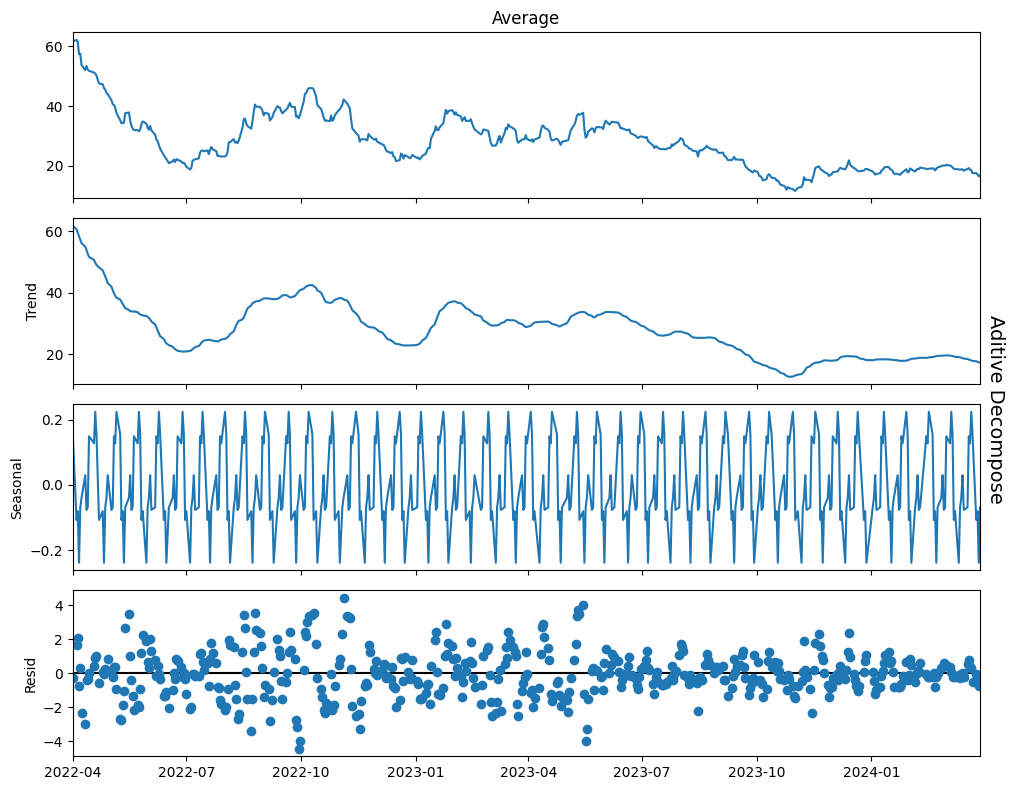

In [13]:
decomposition = sm.tsa.seasonal_decompose(df['Average'], model = 'aditive', period=12, extrapolate_trend=3, two_sided=True)
plt.rcParams.update({'figure.figsize': (10,8)})
decomposition.plot().suptitle('Aditive Decompose', fontsize=14, x=1, y=0.6, rotation=270)
plt.show()

**Observação 1:** O parâmetro two_sided na função seasonal_decompose do statsmodels controla se a decomposição sazonal é feita de forma "bidirecional" ou "unilateral".

Quando two_sided=True, a decomposição é feita em ambas as direções, permitindo que os efeitos sazonais sejam observados tanto antes quanto depois do ponto central. Isso pode ser útil quando os dados exibem sazonalidade simétrica.
Quando two_sided=False, a decomposição é feita de forma unilateral, considerando apenas os dados após o ponto central. Isso pode ser útil quando os dados exibem uma tendência clara e a sazonalidade é mais proeminente em uma direção.
A escolha entre two_sided=True e two_sided=False depende da natureza dos seus dados e do comportamento sazonal que você está tentando capturar na decomposição.

**Obervação 2**: o parâmetro extrapolate_trend controla a extrapolação da tendência resultante da convolução. Aqui está o que significa:

Se for definido como um número inteiro positivo (> 0), a tendência resultante da convolução será extrapolada linearmente em ambas as extremidades (ou em apenas uma extremidade se two_sided for False), considerando esse número +1 de pontos mais próximos.

Por exemplo, se extrapolate_trend for definido como 3, ele usará os 4 pontos mais próximos para extrapolar a tendência.

Se for definido como 'freq', ele usará o número de pontos mais próximo igual ao valor de freq. da série tempora (12 meses - 12 pontos). Definir esse parâmetro resultará em nenhum valor NaN nos componentes de tendência ou resíduo.

Esse parâmetro controla como a tendência é extrapolada para fora dos limites dos seus dados observados. Se definido como um número inteiro, ele extrapola a tendência linearmente usando os pontos mais próximos. Se definido como 'freq', ele usará um número de pontos igual à frequência dos seus dados.

**Insight importante!**

Isso não melhora o modelo —
apenas melhora a visualização e completude da decomposição

Modelo multiplicativo

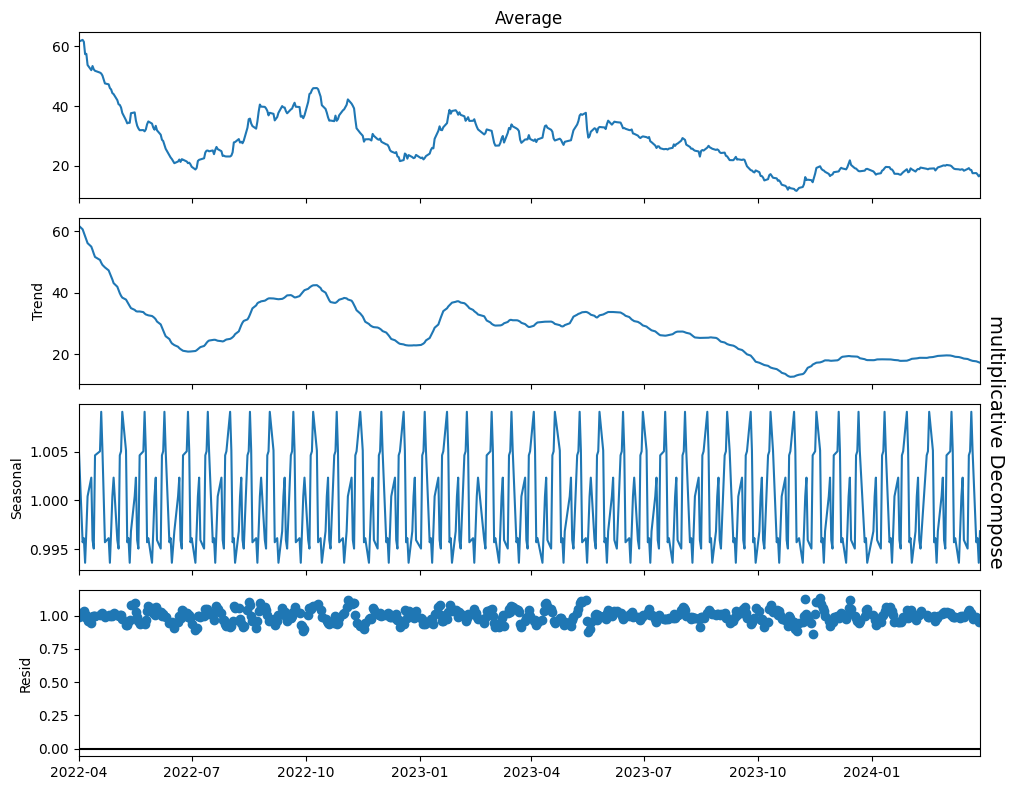

In [14]:
decomposition = sm.tsa.seasonal_decompose(df['Average'], model = 'multiplicative', period=12, extrapolate_trend=3, two_sided=True)
plt.rcParams.update({'figure.figsize': (10,8)})
decomposition.plot().suptitle('multiplicative Decompose', fontsize=14, x=1, y=0.6, rotation=270)
plt.show()

**Explicação sobre a linha preta dos resíduos:**

A linha preta contínua próxima de zero nos gráficos de resíduos representa a componente de tendência dos resíduos. Nos modelos de decomposição de séries temporais, após remover as componentes sazonal, de tendência e opcionalmente de ciclo, o que resta são os resíduos, que são a parte não explicada pelos componentes anteriores.

Idealmente, os resíduos deveriam ser estacionários e aleatórios, o que significa que não deve haver nenhuma tendência discernível neles. No entanto, em muitos casos reais, pode haver uma pequena tendência remanescente nos resíduos, o que é representado pela linha preta contínua próxima de zero nos gráficos de resíduos. Esta linha pode indicar que ainda há alguma informação não capturada pelo modelo ou que há algum padrão nos dados que não foi adequadamente modelado.

Se a linha preta contínua estiver longe de zero ou mostrar um padrão claro, isso pode indicar que o modelo não está capturando completamente a estrutura dos dados ou que há alguma fonte de erro sistemático que não está sendo considerada. Isso pode sugerir a necessidade de ajustes ou refinamentos no modelo.







**Visualizando apenas a tendência**

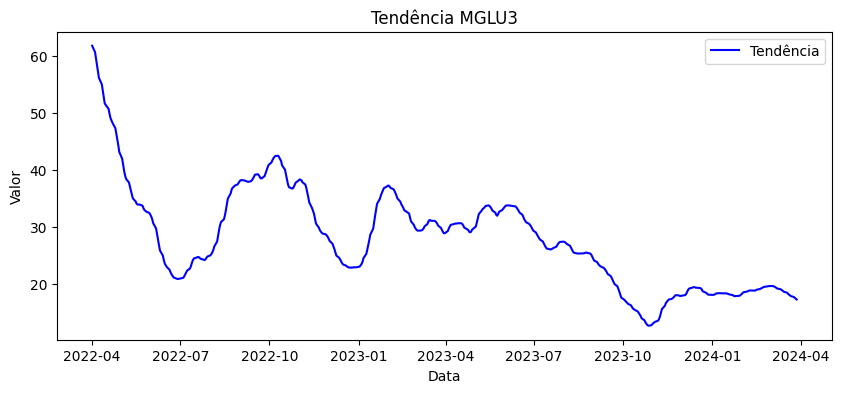

In [15]:
# plot
fig, ax = plt.subplots(figsize=(10, 4))

# Acessar valores da tendência extrapolada
trend = decomposition.trend.dropna()

# Plotar tendência extrapolada
plt.plot(trend.index, trend, color='blue', label='Tendência')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.title('Tendência MGLU3')
plt.legend()
plt.show()

# **Modelagem com o Prophet - previsão e detecção de "change points"**

Acertando os dados para o Prophet

In [16]:
# Criando uma nova coluna que copia o índice
df['Date'] = df.index

# Convertendo a coluna 'Date' para datetime
df['Date'] = pd.to_datetime(df['Date'], unit='s', format='%m%d%Y')

# Criando um novo dataframe com a coluna Date e coluna do preço médio da ação
new_df = df[['Date', 'Average']].reset_index(drop=True)

# Renomeando coluna "Date" para "ds" e coluna "Average" para "y"
new_df.rename(columns={'Date': 'ds', 'Average': 'y'}, inplace=True)

# Verificar o novo DataFrame
new_df.head()

Price,ds,y
Ticker,,
0,2022-04-01,61.658118
1,2022-04-04,62.220219
2,2022-04-05,61.571643
3,2022-04-06,57.420746
4,2022-04-07,57.550457


**Instalação de pacotes necessários**

In [17]:
!pip install numpy cython
!pip install pystan
!pip install prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00


In [18]:
!pip install prophet --no-binary :all:

Apenas se tiver erro na instalação:

In [ ]:
!pip install jedi==0.17.1
!pip install --upgrade setuptools wheel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 16.0 MB/s eta 0:00:00
ERROR: Operation cancelled by user
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.5/821.5 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 67.7.2
    Uninstalling setuptools-67.7.2:
ERROR: Operation cancelled by user


O argumentos:

- **interval_width**: Define a largura do intervalo de confiança para as previsões.

- **growth**: Especifica o tipo de crescimento do modelo. Pode ser 'linear' ou 'logistic'.

- **seasonality_mode**: Define o modo de sazonalidade. Pode ser 'additive' ou 'multiplicative'.

- **changepoint_range**: Define a porcentagem dos dados que é usada para encontrar pontos de mudança na tendência.

- **changepoint_prior_scale**: Define a escala do parâmetro de mudança de tendência. Valores maiores permitem mais pontos de mudança.

- **daily_seasonality**: Se verdadeiro, ativa a sazonalidade diária no modelo.

Para mais informações: https://facebook.github.io/prophet/docs/trend_changepoints.html

**Importante**!

Por padrão, os changepoints são inferidos apenas para os primeiros 80% da série temporal para ter bastante espaço para projetar a tendência para frente e evitar o ajuste excessivo das flutuações no final da série temporal. Este padrão funciona em muitas situações, mas não em todas, e pode ser alterado usando o argumento changepoint_range. Por exemplo, m = Prophet(changepoint_range=0.9) em Python ou m <- prophet(changepoint.range = 0.9) em R colocará changepoints potenciais nos primeiros 90% da série temporal.

Outro argumento importante é o changepoint_prior_scale. Esse argumento controla a flexibilidade do modelo em ajustar os changepoints. Valores menores desse parâmetro tornam o modelo mais rígido, ou seja, menos propenso a ajustar mudanças na tendência. Por outro lado, valores maiores tornam o modelo mais flexível, permitindo mais mudanças na tendência. Um valor de 1 é o padrão, mas pode ser ajustado conforme necessário para melhorar o ajuste do modelo aos dados.

Esses parâmetros permitem controlar explicitamente a estrutura da série temporal, ajustando a flexibilidade do modelo entre rigidez estatística e adaptação aos dados.

**De forma bem direta:** No Prophet, não é o dado que manda no modelo —
é o modelo que decide quanto confiar no dado.

In [19]:
from prophet import Prophet
# Make the prophet model and fit on the df
model = Prophet(interval_width=0.95, growth='linear', seasonality_mode='additive', changepoint_range=1, changepoint_prior_scale=1, daily_seasonality=True)
model.fit(new_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [20]:
# Make a future dataframe for 30 days
future = model.make_future_dataframe(periods=30, freq='D')
print(future)

            ds
0   2022-04-01
1   2022-04-04
2   2022-04-05
3   2022-04-06
4   2022-04-07
..         ...
522 2024-04-23
523 2024-04-24
524 2024-04-25
525 2024-04-26
526 2024-04-27

[527 rows x 1 columns]


In [21]:
# Make predictions
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2022-04-01,61.286712,57.335481,65.064217
1,2022-04-04,59.511326,55.347333,63.290861
2,2022-04-05,58.791574,54.907791,62.428674
3,2022-04-06,57.984225,54.020087,61.842713
4,2022-04-07,57.390361,53.526397,61.205597


- ds: data da previsão
- yhat: o valor previsto da nossa métrica (em Estatísticas, yhat é uma notação - tradicionalmente usada para representar os valores previstos de um valor y)
- yhat_lower: o limite inferior da previsão
- yhat_upper: o limite superior da previsão

Visualizando os dados da previsão

In [22]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(27)

,ds,yhat,yhat_lower,yhat_upper
500,2024-04-01,17.612865,13.568939,21.746436
501,2024-04-02,17.491885,13.618821,21.568575
502,2024-04-03,17.283306,13.263501,21.464672
503,2024-04-04,17.288213,13.287321,21.347645
504,2024-04-05,17.173509,13.209329,20.994676
505,2024-04-06,16.362090,12.162711,20.522441
506,2024-04-07,16.302314,12.534082,20.608012
507,2024-04-08,17.194435,13.072972,21.525700
508,2024-04-09,17.073455,12.795177,21.568522
509,2024-04-10,16.864877,12.366216,21.694337


Visualizando modelo e sazonalidade

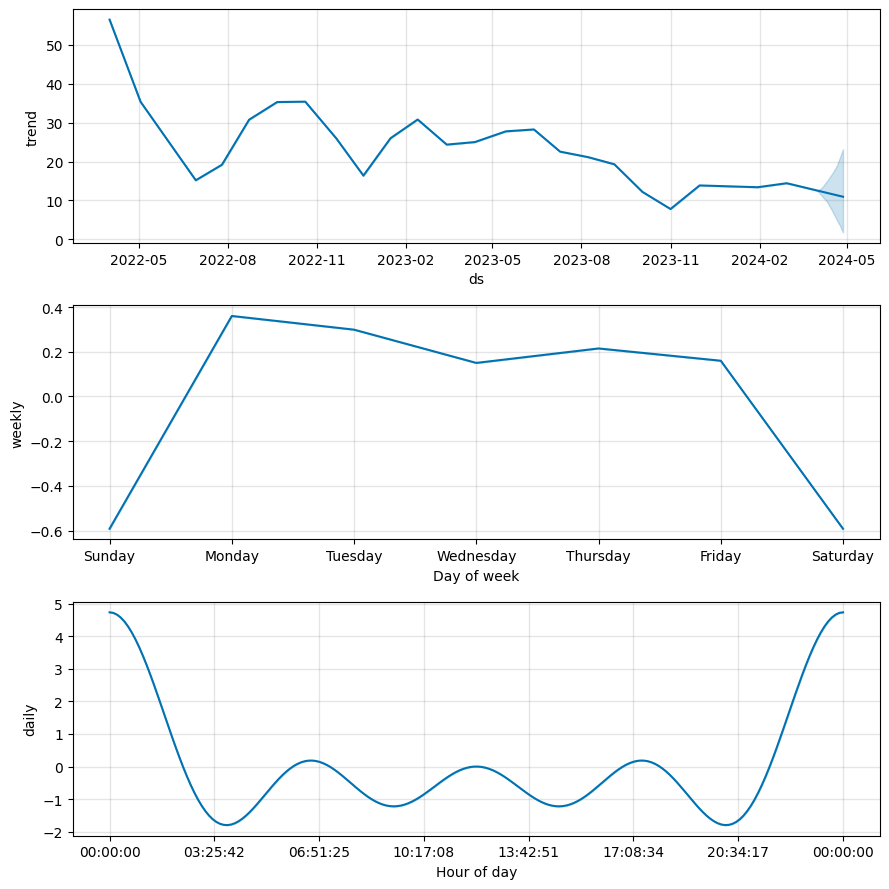

In [23]:
fig1 = model.plot_components(forecast)

**O que é o eixo Y nesses gráficos do Prophet?**
- Não é o valor do ativo (preço)
- É o efeito da componente sobre o valor final

y(t) = tendência + sazonalidade + erro

Isso demonstra o quanto a sazonalidade influência no valor das obeservações.

Ex: segunda mais otimista, sexta mais conservadora.



**E a diária?**
- Nossos dados são diários?

Correção: Prophet(
    daily_seasonality=False,
    weekly_seasonality=True
)

**Pergunta:**

- Se o modelo consegue gerar padrões mesmo quando eles não existem…
até que ponto podemos confiar nos resultados?

Visualizando o modelo, previsão e observações

---



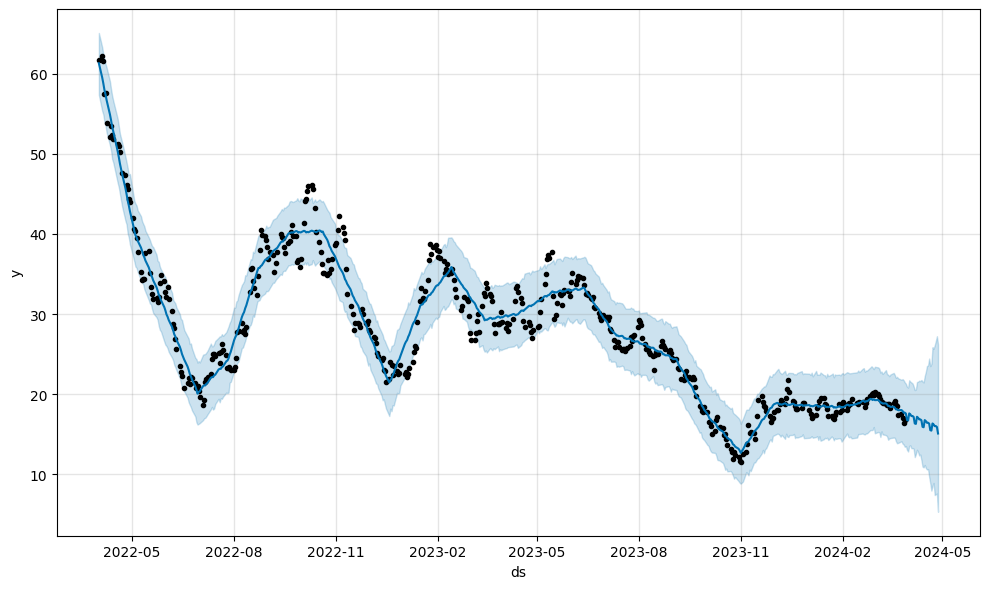

In [24]:
model.plot(forecast, uncertainty=True);

**Pergunta?**

- Percebe algo diferente da decomposição no modelo do Prophet?

Detecção de change point

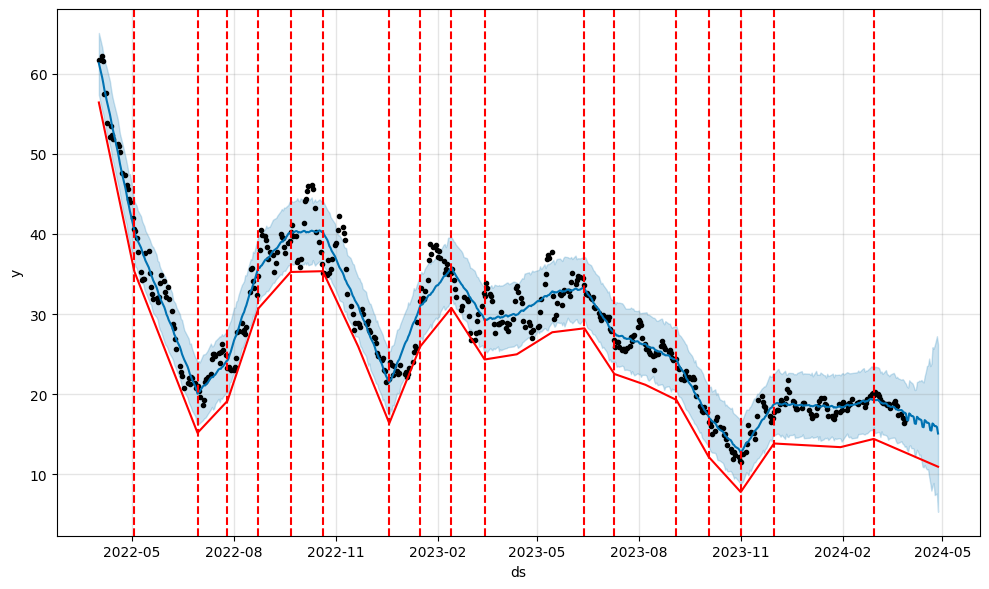

In [26]:
from prophet.plot import add_changepoints_to_plot
fig = model.plot(forecast, uncertainty=True);
a = add_changepoints_to_plot(fig.gca(), model, forecast, threshold = 1);

**Importante!**

Diferente de modelos autorregressivos, o Prophet modela explicitamente a tendência como uma função que pode mudar ao longo do tempo.

E ai está o diferencial!

- Média móvel "filtra a tendência" → via vizinhos, valores pŕoximos

- ARIMA captura padrões → via autocorrelação - indireto (lags, diferenciação)

- Prophet modela tendência → explicitamente com changepoints -direto (quebras de tendência)